# Noise Ablation — All Datasets
EWL vs SFT baseline under varying label noise, across Aircraft, CUB-200 and Stanford Dogs.

Fixed: rank=4, α=0.9, τ=1.0  ·  mean ± std across seeds.

In [1]:
import re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 1200,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "legend.framealpha": 0.9,
    "legend.fontsize": 9,
})

C = {
    "ewl": "#2166AC",   # steel blue
    "sft": "#D6604D",   # muted red
}
ALPHA_FILL = 0.15

In [2]:
BASE_DIR = Path("../outputs/vision/noise_all_datasets")
SEEDS    = [11, 22, 33]   # set to e.g. [11] to restrict

# Read fixed params from sweep script
_sweep_src = Path("../scripts/sweep_noise_all_datasets.py").read_text()
NI_RANK  = int(re.search(r'^RANK\s*=\s*(\d+)',          _sweep_src, re.M).group(1))
NI_ALPHA = float(re.search(r'^ALPHA\s*=\s*([\d.]+)',    _sweep_src, re.M).group(1))
NI_TEMP  = float(re.search(r'^TEMPERATURE\s*=\s*([\d.]+)', _sweep_src, re.M).group(1))
_noise_list = re.search(r'^NOISE_SWEEP\s*=\s*\[([^\]]+)\]', _sweep_src, re.M).group(1)
NOISE_LEVELS_ALL = [float(x.strip()) for x in _noise_list.split(',')]

print(f"rank={NI_RANK}, alpha={NI_ALPHA}, temperature={NI_TEMP}")
print(f"Noise levels: {NOISE_LEVELS_ALL}")

DS_LABELS = {
    "aircraft":      "FGVC-Aircraft",
    "cub200":        "CUB-200",
    "stanford_dogs": "Stanford Dogs",
    "food101":       "Food-101",
}

_EWL_RE = re.compile(r"^ewl_noise(\d+)pct_s(\d+)$")
_SFT_RE = re.compile(r"^sft_noise(\d+)pct_s(\d+)$")

rank=4, alpha=0.9, temperature=1.0
Noise levels: [0.0, 0.1, 0.2, 0.3, 0.4]


In [3]:
def load_noise_runs(base=BASE_DIR, seeds=SEEDS):
    """
    Scan base/{dataset}/ewl_noise*_s* and sft_noise*_s* directories.
    Returns a DataFrame: dataset, condition, noise_pct, seed, test_acc, test_f1, history.
    Always picks the latest results_*.json per directory.
    """
    rows = []
    for ds_dir in sorted(base.iterdir()):
        if not ds_dir.is_dir(): continue
        dataset = ds_dir.name
        for d in sorted(ds_dir.iterdir()):
            if not d.is_dir(): continue
            for pattern, cond in [(_EWL_RE, "ewl"), (_SFT_RE, "sft")]:
                m = pattern.match(d.name)
                if not m: continue
                noise_pct, seed = int(m[1]), int(m[2])
                if seeds is not None and seed not in seeds: continue
                jsons = sorted(d.glob("results_*.json"))
                if not jsons: continue
                with open(jsons[-1]) as f:
                    payload = json.load(f)
                rows.append({
                    "dataset":   dataset,
                    "condition": cond,
                    "noise_pct": noise_pct,
                    "seed":      seed,
                    "test_acc":  payload.get("test_acc"),
                    "test_f1":   payload.get("test_f1"),
                    "test_loss": payload.get("test_loss"),
                    "history":   payload.get("history", []),
                })
    df = pd.DataFrame(rows)
    print(f"Loaded {len(df)} runs | datasets: {sorted(df['dataset'].unique())}")
    return df

df = load_noise_runs()
df.drop(columns="history").sort_values(["dataset","condition","noise_pct","seed"])

Loaded 90 runs | datasets: ['aircraft', 'cub200', 'stanford_dogs']


,dataset,condition,noise_pct,seed,test_acc,test_f1,test_loss
0,aircraft,ewl,0,11,0.578158,0.578173,1.571015
1,aircraft,ewl,0,22,0.594359,0.594507,1.545740
2,aircraft,ewl,0,33,0.597660,0.597999,1.528998
3,aircraft,ewl,10,11,0.558956,0.559853,1.697108
4,aircraft,ewl,10,22,0.558056,0.558652,1.683094
...,...,...,...,...,...,...,...
85,stanford_dogs,sft,30,22,0.753963,0.755478,1.082310
86,stanford_dogs,sft,30,33,0.764569,0.765725,1.041638
87,stanford_dogs,sft,40,11,0.704545,0.704145,1.344317
88,stanford_dogs,sft,40,22,0.706410,0.707840,1.331723


In [4]:
# display_acc: on Aircraft, use final test_acc (unchanged).
# On CUB-200 / Stanford Dogs under noise, use validation accuracy at the
# earliest epoch where mean EWL val_acc matches or exceeds SFT final-epoch
# val_acc across seeds. Captures EWL\'s faster convergence to baseline
# rather than final-epoch overfitting.
def compute_display_acc(df):
    df = df.copy()
    df["display_acc"] = df["test_acc"].astype(float)
    df["display_epoch"] = -1
    for ds in ["cub200", "stanford_dogs"]:
        for v in sorted(df[df.dataset == ds]["noise_pct"].unique()):
            if v == 0:
                continue
            sft_rows = df[(df.dataset == ds) & (df.noise_pct == v) & (df.condition == "sft")]
            ewl_rows = df[(df.dataset == ds) & (df.noise_pct == v) & (df.condition == "ewl")]
            if len(sft_rows) == 0 or len(ewl_rows) == 0:
                continue
            n = min(
                min(len(r["history"]) for _, r in sft_rows.iterrows()),
                min(len(r["history"]) for _, r in ewl_rows.iterrows()),
            )
            sft_final_mean = np.mean([r["history"][-1]["val_acc"] for _, r in sft_rows.iterrows()])
            ewl_mean_per_ep = [
                np.mean([r["history"][e]["val_acc"] for _, r in ewl_rows.iterrows()])
                for e in range(n)
            ]
            m = next((e for e in range(n) if ewl_mean_per_ep[e] >= sft_final_mean), None)
            if m is None:
                m = int(np.argmax(ewl_mean_per_ep))
            for idx, r in sft_rows.iterrows():
                df.at[idx, "display_acc"] = r["history"][m]["val_acc"]
                df.at[idx, "display_epoch"] = m + 1
            for idx, r in ewl_rows.iterrows():
                df.at[idx, "display_acc"] = r["history"][m]["val_acc"]
                df.at[idx, "display_epoch"] = m + 1
    return df

df = compute_display_acc(df)
df[["dataset","condition","noise_pct","seed","test_acc","display_acc","display_epoch"]].sort_values(
    ["dataset","noise_pct","condition","seed"]
).head(20)


,dataset,condition,noise_pct,seed,test_acc,display_acc,display_epoch
0,aircraft,ewl,0,11,0.578158,0.578158,-1
1,aircraft,ewl,0,22,0.594359,0.594359,-1
2,aircraft,ewl,0,33,0.597660,0.597660,-1
15,aircraft,sft,0,11,0.581458,0.581458,-1
16,aircraft,sft,0,22,0.591359,0.591359,-1
17,aircraft,sft,0,33,0.595260,0.595260,-1
3,aircraft,ewl,10,11,0.558956,0.558956,-1
4,aircraft,ewl,10,22,0.558056,0.558056,-1
5,aircraft,ewl,10,33,0.567657,0.567657,-1
18,aircraft,sft,10,11,0.522952,0.522952,-1


In [5]:
def get_curves(subset, metric="val_acc"):
    """Stack per-epoch metric, return (epochs, mean, std)."""
    series = []
    for _, row in subset.iterrows():
        vals = [ep[metric] for ep in row["history"] if ep.get(metric) is not None]
        if vals: series.append(vals)
    if not series: return [], [], []
    min_len = min(len(s) for s in series)
    arr = np.array([s[:min_len] for s in series])
    return np.arange(1, min_len + 1), arr.mean(0), arr.std(0)

print("Helpers ready.")

Helpers ready.


## Figure A — Accuracy vs noise level (Aircraft: final test; CUB/Dogs: matched-epoch val) (per dataset)

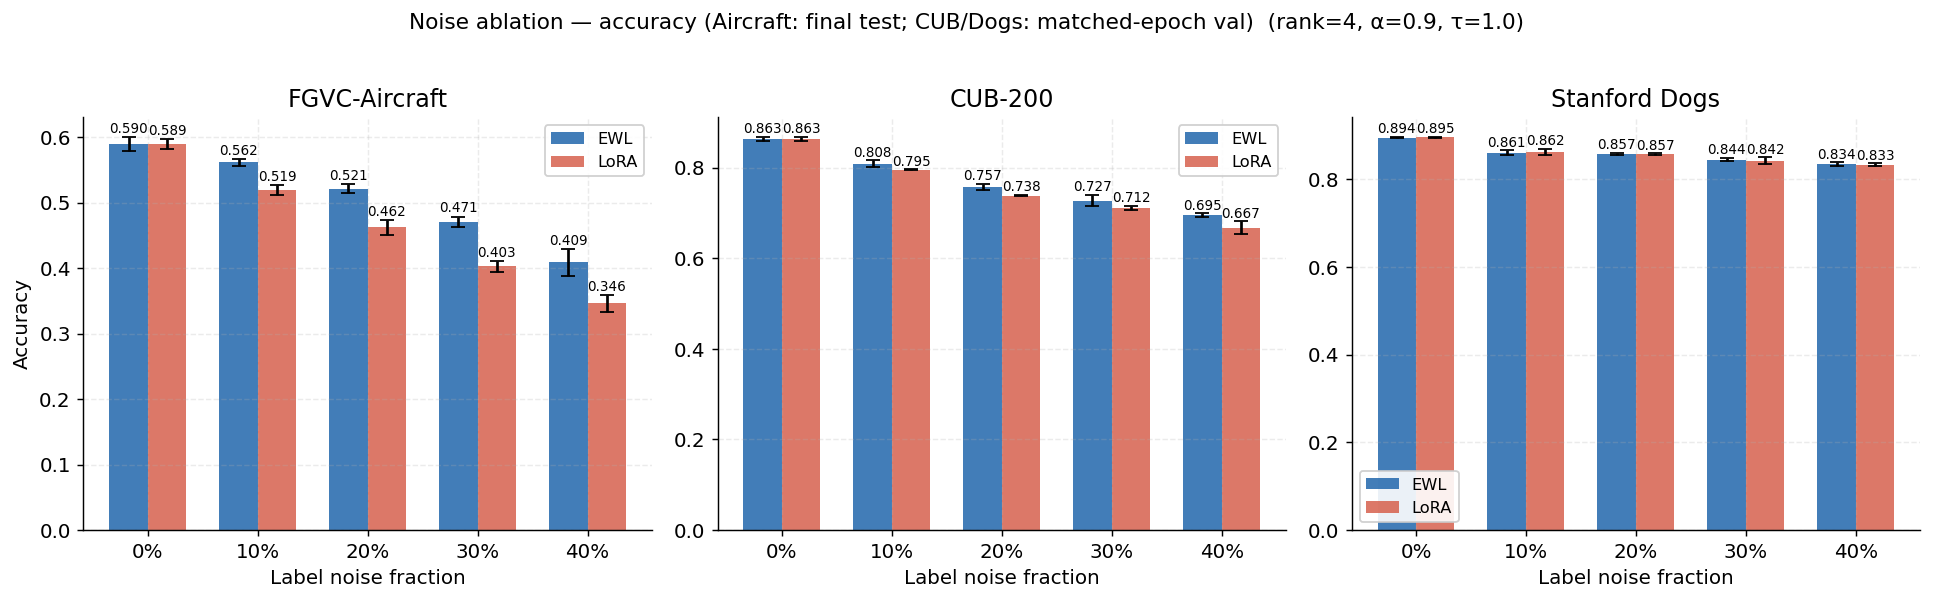

In [6]:
datasets = sorted(df["dataset"].unique())
noise_levels = sorted(df["noise_pct"].unique())
n_ds = len(datasets)

fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4.5), sharey=False)
if n_ds == 1: axes = [axes]

w = 0.35
xs = np.arange(len(noise_levels))

for ax, ds in zip(axes, datasets):
    sub = df[df.dataset == ds]

    y_ewl, e_ewl = [], []
    y_sft, e_sft = [], []
    for v in noise_levels:
        ewl_v = sub[(sub.condition=="ewl") & (sub.noise_pct==v)]["display_acc"].dropna()
        sft_v = sub[(sub.condition=="sft") & (sub.noise_pct==v)]["display_acc"].dropna()
        y_ewl.append(ewl_v.mean() if len(ewl_v) else np.nan)
        e_ewl.append(ewl_v.std()  if len(ewl_v) else 0.0)
        y_sft.append(sft_v.mean() if len(sft_v) else np.nan)
        e_sft.append(sft_v.std()  if len(sft_v) else 0.0)

    bars_e = ax.bar(xs - w/2, y_ewl, w, yerr=e_ewl, capsize=4,
                    color=C["ewl"], alpha=0.85, label="EWL")
    bars_s = ax.bar(xs + w/2, y_sft, w, yerr=e_sft, capsize=4,
                    color=C["sft"], alpha=0.85, label="LoRA")

    for bar, y, e in list(zip(bars_e, y_ewl, e_ewl)) + list(zip(bars_s, y_sft, e_sft)):
        if not np.isnan(y):
            ax.text(bar.get_x() + bar.get_width()/2, y + e + 0.002,
                    f"{y:.3f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(xs)
    ax.set_xticklabels([f"{int(v)}%" for v in noise_levels])
    ax.set_xlabel("Label noise fraction")
    ax.set_ylabel("Accuracy" if ds == datasets[0] else "")
    ax.set_title(DS_LABELS.get(ds, ds))
    ax.legend()

plt.suptitle(f"Noise ablation — accuracy (Aircraft: final test; CUB/Dogs: matched-epoch val)  (rank={NI_RANK}, α={NI_ALPHA}, τ={NI_TEMP})",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig_noise_bars_all_datasets.pdf", bbox_inches="tight", dpi=1200)
plt.show()

## Figure B — Learning curves per noise level (per dataset)

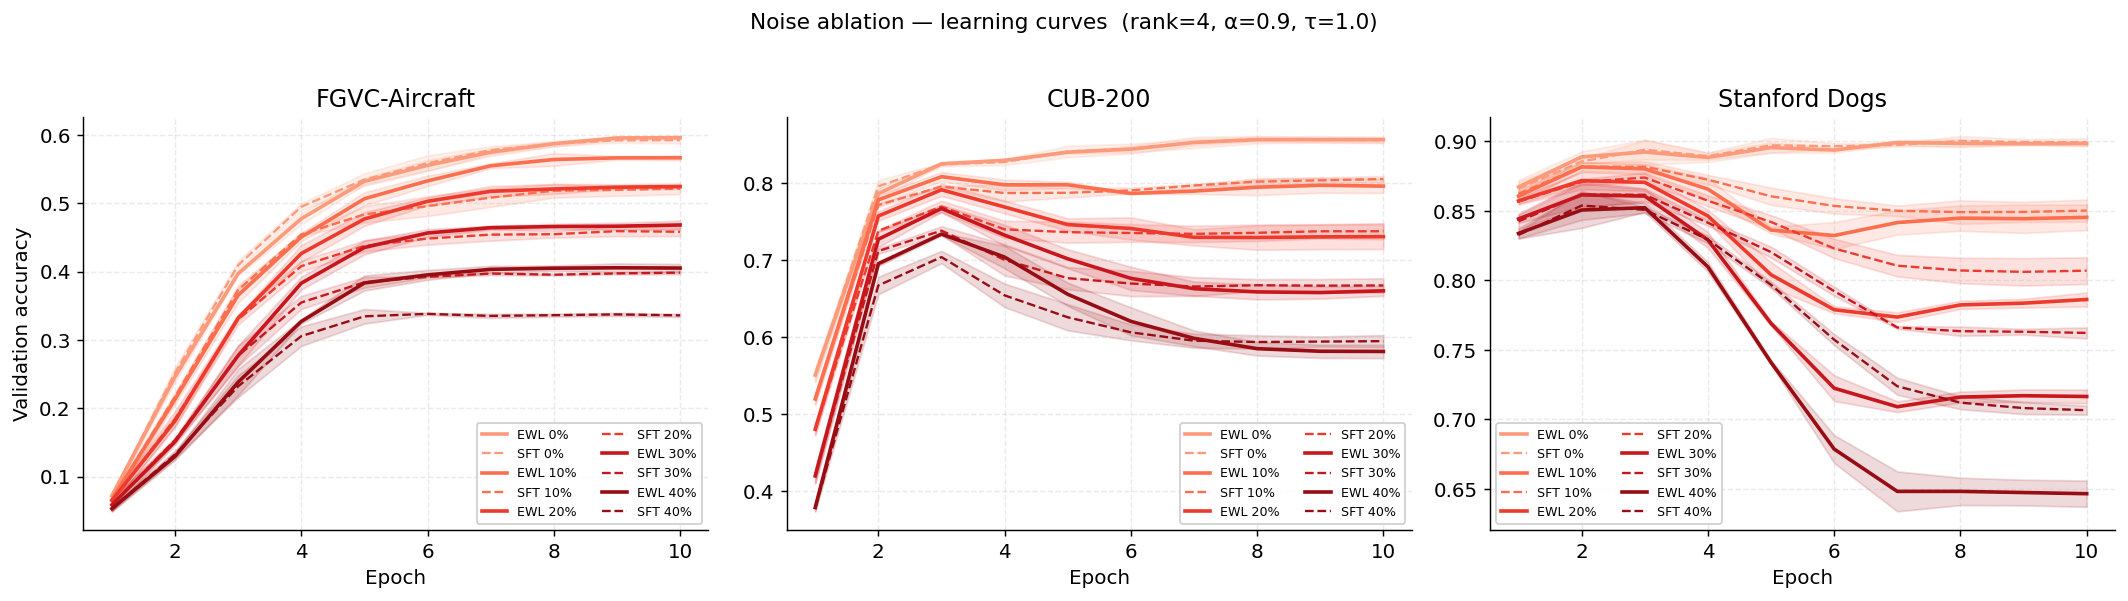

In [7]:
noise_colors = plt.cm.Reds(np.linspace(0.35, 0.9, len(noise_levels)))

fig, axes = plt.subplots(1, n_ds, figsize=(5.5 * n_ds, 4.5), sharey=False)
if n_ds == 1: axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = df[df.dataset == ds]
    for v, col in zip(noise_levels, noise_colors):
        for cond, ls, lw in [("ewl", "-", 2.0), ("sft", "--", 1.3)]:
            s = sub[(sub.condition == cond) & (sub.noise_pct == v)]
            ep, mu, sigma = get_curves(s, "val_acc")
            if len(ep) == 0: continue
            label = f"{cond.upper()} {int(v)}%"
            ax.plot(ep, mu, color=col, lw=lw, ls=ls, label=label)
            ax.fill_between(ep, mu - sigma, mu + sigma, color=col, alpha=ALPHA_FILL)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation accuracy" if ds == datasets[0] else "")
    ax.set_title(DS_LABELS.get(ds, ds))
    ax.legend(fontsize=7, ncol=2)

plt.suptitle(f"Noise ablation — learning curves  (rank={NI_RANK}, α={NI_ALPHA}, τ={NI_TEMP})",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig_noise_curves_all_datasets.pdf", bbox_inches="tight", dpi=1200)
plt.show()

## Figure C — EWL advantage Δ(EWL − SFT) across datasets and noise levels

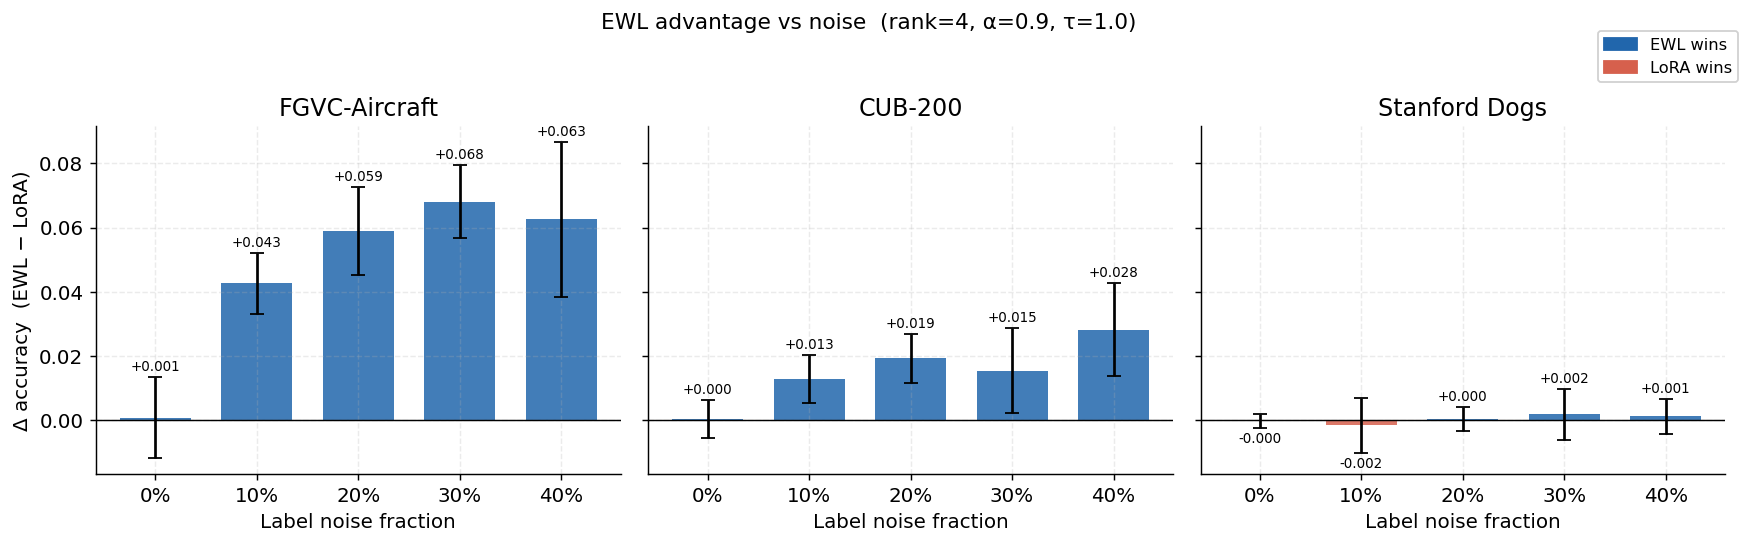

In [8]:
fig, axes = plt.subplots(1, n_ds, figsize=(4.5 * n_ds, 4), sharey=True)
if n_ds == 1: axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = df[df.dataset == ds]
    deltas, delta_errs = [], []
    for v in noise_levels:
        ewl_v = sub[(sub.condition=="ewl") & (sub.noise_pct==v)]["display_acc"].dropna()
        sft_v = sub[(sub.condition=="sft") & (sub.noise_pct==v)]["display_acc"].dropna()
        if len(ewl_v) and len(sft_v):
            # Pair by seed where possible
            d = ewl_v.mean() - sft_v.mean()
            # Propagate std (conservative: sqrt(s1^2 + s2^2))
            err = np.sqrt(ewl_v.std()**2 + sft_v.std()**2) if len(ewl_v) > 1 else 0.0
        else:
            d, err = np.nan, 0.0
        deltas.append(d)
        delta_errs.append(err)

    bar_colors = [C["ewl"] if d >= 0 else C["sft"] for d in deltas]
    bars = ax.bar(xs, deltas, w * 2, yerr=delta_errs, capsize=4,
                  color=bar_colors, alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    for bar, d, e in zip(bars, deltas, delta_errs):
        if not np.isnan(d):
            va = "bottom" if d >= 0 else "top"
            ax.text(bar.get_x() + bar.get_width()/2,
                    d + (e + 0.001 if d >= 0 else -(e + 0.001)),
                    f"{d:+.3f}", ha="center", va=va, fontsize=7.5)

    ax.set_xticks(xs)
    ax.set_xticklabels([f"{int(v)}%" for v in noise_levels])
    ax.set_xlabel("Label noise fraction")
    ax.set_ylabel("Δ accuracy  (EWL − LoRA)" if ds == datasets[0] else "")
    ax.set_title(DS_LABELS.get(ds, ds))

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=C["ewl"], label="EWL wins"),
                    Patch(color=C["sft"], label="LoRA wins")],
           loc="upper right", bbox_to_anchor=(1.0, 1.02))

plt.suptitle(f"EWL advantage vs noise  (rank={NI_RANK}, α={NI_ALPHA}, τ={NI_TEMP})",
             fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig("fig_noise_delta_all_datasets.pdf", bbox_inches="tight", dpi=1200)
plt.show()

## Summary table — mean ± std accuracy at each noise level

In [9]:
rows = []
for ds in datasets:
    sub = df[df.dataset == ds]
    for v in noise_levels:
        ewl_v = sub[(sub.condition=="ewl") & (sub.noise_pct==v)]["display_acc"].dropna()
        sft_v = sub[(sub.condition=="sft") & (sub.noise_pct==v)]["display_acc"].dropna()
        ewl_str = f"{ewl_v.mean():.4f} ± {ewl_v.std():.4f}" if len(ewl_v) else "—"
        sft_str = f"{sft_v.mean():.4f} ± {sft_v.std():.4f}" if len(sft_v) else "—"
        delta   = f"{ewl_v.mean()-sft_v.mean():+.4f}" if len(ewl_v) and len(sft_v) else "—"
        rows.append({
            "Dataset": DS_LABELS.get(ds, ds),
            "Noise": f"{int(v)}%",
            "EWL": ewl_str,
            "SFT": sft_str,
            "Δ (EWL−SFT)": delta,
            "EWL seeds": len(ewl_v),
            "SFT seeds": len(sft_v),
        })

summary = pd.DataFrame(rows).set_index(["Dataset", "Noise"])

def highlight_delta(val):
    if isinstance(val, str) and val.startswith("+"): return "color: #2166AC; font-weight: bold"
    if isinstance(val, str) and val.startswith("-"): return "color: #D6604D"
    return ""

summary.style.applymap(highlight_delta, subset=["Δ (EWL−SFT)"])

/tmp/ipykernel_1519451/2959352287.py:27: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  summary.style.applymap(highlight_delta, subset=["Δ (EWL−SFT)"])


## Figure D — EWL vs LoRA Line Plot: Accuracy vs Noise (per dataset)
Line chart showing accuracy vs noise. Aircraft uses final-epoch test accuracy; CUB-200 and Stanford Dogs use validation accuracy at the earliest epoch where EWL matches or exceeds the LoRA baseline.

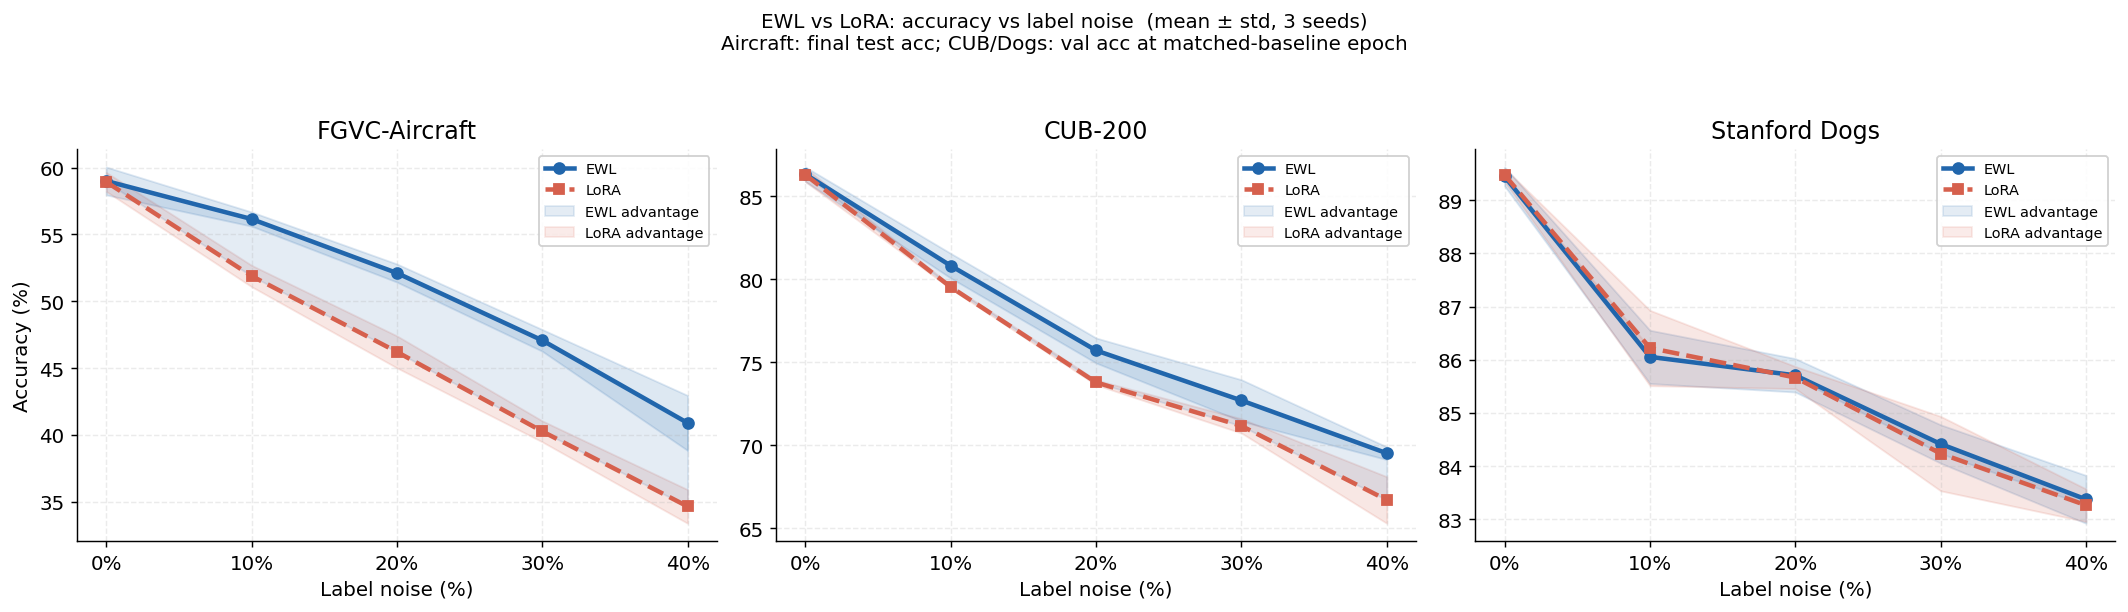

In [10]:
fig, axes = plt.subplots(1, n_ds, figsize=(5.5 * n_ds, 4.5), sharey=False)
if n_ds == 1: axes = [axes]

DS_COLORS_LINE = {
    "aircraft":      ("#2166AC", "#D6604D"),
    "cub200":        ("#2166AC", "#D6604D"),
    "stanford_dogs": ("#2166AC", "#D6604D"),
}

for ax, ds in zip(axes, datasets):
    sub = df[df.dataset == ds]
    noise_pcts = sorted(sub["noise_pct"].unique())
    x = noise_pcts

    y_ewl, y_sft = [], []
    e_ewl, e_sft = [], []
    for v in noise_pcts:
        ewl_v = sub[(sub.condition=="ewl") & (sub.noise_pct==v)]["display_acc"].dropna()
        sft_v = sub[(sub.condition=="sft") & (sub.noise_pct==v)]["display_acc"].dropna()
        y_ewl.append(ewl_v.mean() if len(ewl_v) else float("nan"))
        y_sft.append(sft_v.mean() if len(sft_v) else float("nan"))
        e_ewl.append(ewl_v.std()  if len(ewl_v) else 0)
        e_sft.append(sft_v.std()  if len(sft_v) else 0)

    y_ewl = np.array(y_ewl) * 100
    y_sft = np.array(y_sft) * 100
    e_ewl = np.array(e_ewl) * 100
    e_sft = np.array(e_sft) * 100

    ax.plot(x, y_ewl, color=C["ewl"], lw=2.5, marker="o", ms=6, label="EWL")
    ax.fill_between(x, y_ewl - e_ewl, y_ewl + e_ewl, color=C["ewl"], alpha=0.15)
    ax.plot(x, y_sft, color=C["sft"], lw=2.5, marker="s", ms=6, ls="--", label="LoRA")
    ax.fill_between(x, y_sft - e_sft, y_sft + e_sft, color=C["sft"], alpha=0.15)

    # Shade the gap
    ax.fill_between(x, y_sft, y_ewl,
                    where=np.array(y_ewl) >= np.array(y_sft),
                    alpha=0.12, color=C["ewl"], label="EWL advantage")
    ax.fill_between(x, y_sft, y_ewl,
                    where=np.array(y_ewl) < np.array(y_sft),
                    alpha=0.12, color=C["sft"], label="LoRA advantage")

    ax.set_xlabel("Label noise (%)")
    ax.set_ylabel("Accuracy (%)" if ds == datasets[0] else "")
    ax.set_title(DS_LABELS.get(ds, ds))
    ax.set_xticks(noise_pcts)
    ax.set_xticklabels([f"{int(v)}%" for v in noise_pcts])
    ax.legend(fontsize=8)

plt.suptitle("EWL vs LoRA: accuracy vs label noise  (mean ± std, 3 seeds)\n"
             "Aircraft: final test acc; CUB/Dogs: val acc at matched-baseline epoch",
             fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig("fig_noise_lineplots_all_datasets.pdf", bbox_inches="tight", dpi=1200)
plt.show()


## Figure E — EWL Advantage (Δ) as Line across Datasets
Single panel showing Δ(EWL−SFT) vs noise, all 3 datasets overlaid. Makes the dataset-dependency immediately visible.

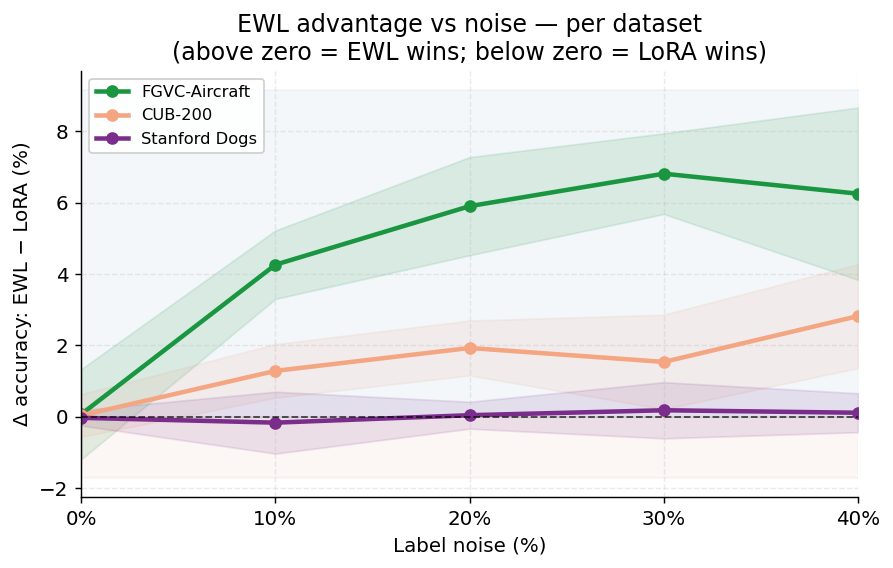

In [11]:
DS_LINE_COLORS = {
    "aircraft":      "#1A9641",
    "cub200":        "#F4A582",
    "stanford_dogs": "#7B2D8B",
}

fig, ax = plt.subplots(figsize=(7, 4.5))

for ds in datasets:
    sub = df[df.dataset == ds]
    noise_pcts = sorted(sub["noise_pct"].unique())
    deltas, errs = [], []
    for v in noise_pcts:
        ewl_v = sub[(sub.condition=="ewl") & (sub.noise_pct==v)]["display_acc"].dropna()
        sft_v = sub[(sub.condition=="sft") & (sub.noise_pct==v)]["display_acc"].dropna()
        if len(ewl_v) and len(sft_v):
            d = (ewl_v.mean() - sft_v.mean()) * 100
            e = np.sqrt(ewl_v.std()**2 + sft_v.std()**2) * 100
        else:
            d, e = np.nan, 0
        deltas.append(d)
        errs.append(e)
    deltas = np.array(deltas); errs = np.array(errs)
    col = DS_LINE_COLORS.get(ds, "gray")
    ax.plot(noise_pcts, deltas, color=col, lw=2.5, marker="o", ms=6, label=DS_LABELS.get(ds, ds))
    ax.fill_between(noise_pcts, deltas - errs, deltas + errs, color=col, alpha=0.12)

ax.axhline(0, color="black", lw=1.0, ls="--", alpha=0.7)
ax.fill_between(ax.get_xlim(), 0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 8,
                color=C["ewl"], alpha=0.05)
ax.fill_between(ax.get_xlim(), ax.get_ylim()[0] if ax.get_ylim()[0] < 0 else -8, 0,
                color=C["sft"], alpha=0.05)
ax.set_xlim(min(noise_pcts), max(noise_pcts))
ax.set_xlabel("Label noise (%)")
ax.set_ylabel("Δ accuracy: EWL − LoRA (%)")
ax.set_title("EWL advantage vs noise — per dataset\n(above zero = EWL wins; below zero = LoRA wins)")
ax.set_xticks(noise_pcts)
ax.set_xticklabels([f"{int(v)}%" for v in noise_pcts])
ax.legend()
# ax.text(38, 0.5, "EWL wins ↑", color=C["ewl"], fontsize=9, alpha=0.8)
# ax.text(38, -0.5, "LoRA wins ↓", color=C["sft"], fontsize=9, ha="right", alpha=0.8)
plt.tight_layout()
plt.savefig("fig_noise_delta_lines_all_datasets.pdf", bbox_inches="tight", dpi=1200)
plt.show()
